# Part 3 - Overlays and diagnostics

This notebook reloads the graph and adds two overlays that cut across the
`mechanism x time` layers. First, one **compartment slice** per organelle: a slice
is a membership overlay on the shared graph and duplicates no topology (the common
alternative keeps one graph object per compartment). Compartments are time-
invariant, so a protein joins its organelle slice regardless of when it responds.
Second, the notebook reports the **time diagnostics** - how the response grows
across the layers - and re-saves the snapshot with the slices attached.

In [1]:
import polars as pl

import uc2b_common as uc

G = uc.load()

# Assign a compartment to each protein from HPA subcellular location (time-invariant).
hpa = pl.read_csv(str(uc.DATA / "proteinatlas.tsv"), separator="\t", infer_schema_length=10000)
loc = dict(zip(hpa["Gene"].to_list(), hpa["Subcellular main location"].to_list()))
V = G.views.vertices().to_pandas()
prot = V[V.vertex_id.str.startswith("prot:")]
comp_of = {r.vertex_id: uc.compartment_code(loc.get(r.gene_symbol)) for r in prot.itertuples(index=False)}
G.attrs.set_vertex_attrs_bulk({v: {"compartment": c} for v, c in comp_of.items()})

# One slice per organelle, over the bare protein vertex ids.
from collections import defaultdict
by_comp = defaultdict(set)
for v, c in comp_of.items():
    name = uc.CODE_TO_NAME.get(c)
    if name:
        by_comp[name].add(v)

rows = []
for name, vids in by_comp.items():
    if G.slices.exists(name):
        continue
    G.slices.add(name)
    for v in vids:
        G.slices.add_vertex_to_slice(name, v)
    eids = [e for e, (s, t, _) in G.edge_definitions.items()
            if uc.bare_vid(s) in vids and uc.bare_vid(t) in vids]
    G.slices.add_edges(name, eids)
    rows.append({"slice": name, "vertices": len(G.slices.vertices(name)),
                 "edges": len(G.slices.edges(name))})
G.history.snapshot("after_organelle_slices")

import pandas as pd
sl = pd.DataFrame(rows).sort_values("vertices", ascending=False)
sl.to_csv(uc.TABLES / "organelle_slices.csv", index=False)
print(sl.to_string(index=False))

          slice  vertices  edges
        cytosol      3469   5370
        nucleus      3251   6451
   mitochondria       609    229
plasma_membrane       513   1421
       vesicles       490    350
          golgi       369    294
             er       277    218
       lysosome        17      7
     peroxisome        11      7


## Time diagnostics

The panel reports the per-timepoint size of each mechanism layer and the two
coupling families, then plots how the responsive signaling and regulatory
populations grow from 1h to 96h - the spreading TGF-beta response the multilayer
expansion captures.

edges by edge_kind:
 edge_kind
signaling               26330
None                    12971
regulatory              10162
coupling_time            7660
complex                  3446
coupling_translation     3322

responsive signaling proteins per t: {'1h': 107, '12h': 815, '24h': 1131, '48h': 1651, '72h': 1955, '96h': 2984}
responsive regulatory genes per t   : {'1h': 116, '12h': 513, '24h': 750, '48h': 1063, '72h': 1221, '96h': 1840}


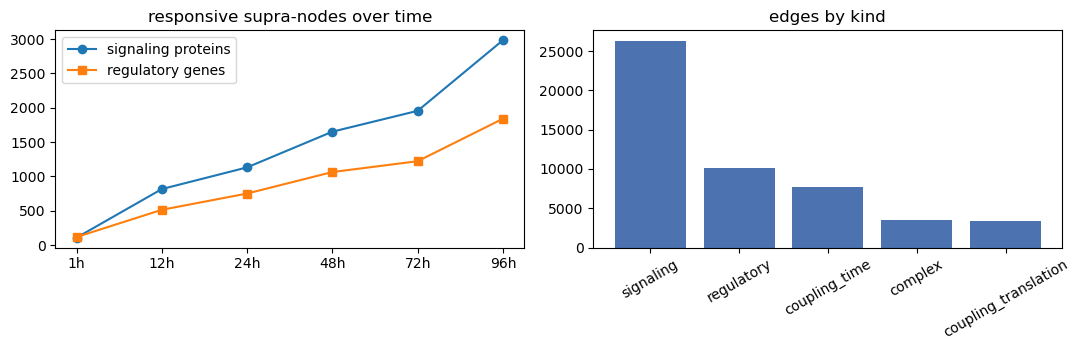

re-saved snapshot with 20 slices


In [2]:
import matplotlib.pyplot as plt

E = uc.edges_frame(G)


def layer_of(coord_repr):
    """Extract the time coordinate from a supra-node repr string."""
    inner = coord_repr[coord_repr.find("(", 2):]
    for t in uc.ALL_TIMES:
        if f"'{t}'" in inner:
            return t
    return None

Eintra = G.views.edges().to_pandas()
Eintra = Eintra[Eintra.ml_kind == "intra"].copy()
Eintra["t"] = Eintra["source"].map(layer_of)
Eintra["mech"] = Eintra["edge_kind"]

print("edges by edge_kind:\n", E["edge_kind"].value_counts(dropna=False).to_string())

sig_v = [len(G.layers.layer_vertex_set((uc.MECH_SIGNALING, t))) for t in uc.TIMES]
reg_v = [len(G.layers.layer_vertex_set((uc.MECH_REGULATORY, t))) for t in uc.TIMES]
print("\nresponsive signaling proteins per t:", dict(zip(uc.TIMES, sig_v)))
print("responsive regulatory genes per t   :", dict(zip(uc.TIMES, reg_v)))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
x = range(len(uc.TIMES))
ax[0].plot(x, sig_v, "o-", label="signaling proteins")
ax[0].plot(x, reg_v, "s-", label="regulatory genes")
ax[0].set_xticks(list(x)); ax[0].set_xticklabels(uc.TIMES)
ax[0].set_title("responsive supra-nodes over time"); ax[0].legend()
counts = E["edge_kind"].value_counts()
ax[1].bar(counts.index, counts.values, color="#4c72b0")
ax[1].set_title("edges by kind"); ax[1].tick_params(axis="x", rotation=30)
fig.tight_layout(); fig.savefig(uc.FIGS / "time_topology.png", dpi=120); plt.show()

G.write(str(uc.SNAPSHOT), overwrite=True)
print("re-saved snapshot with", len(G.slices.list()), "slices")